In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.shape

(7043, 21)

In [3]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

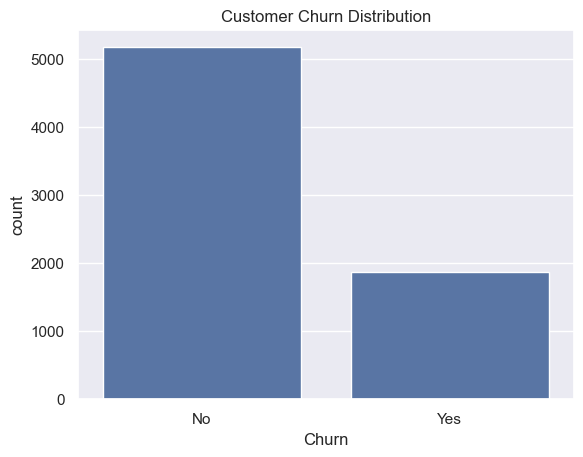

In [7]:
sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")
plt.show()

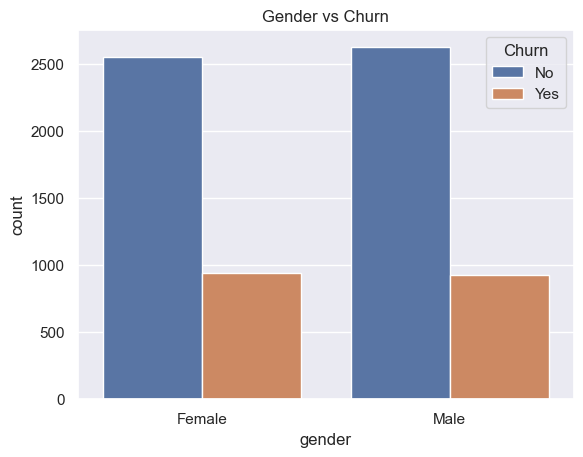

In [9]:
sns.countplot(x="gender", hue="Churn", data=df)

plt.title("Gender vs Churn")
plt.show()

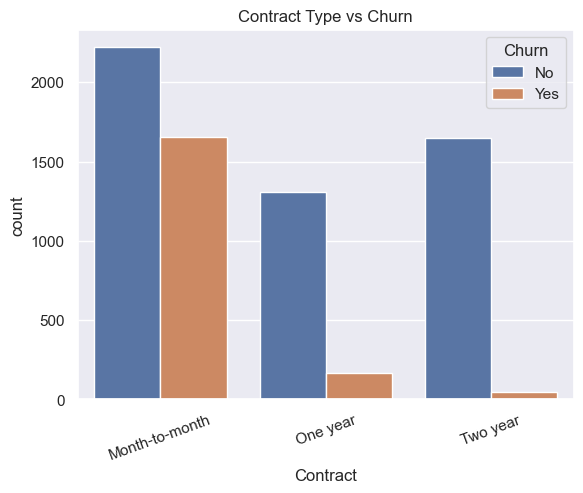

In [10]:
sns.countplot(x="Contract", hue="Churn", data=df)

plt.xticks(rotation=20)

plt.title("Contract Type vs Churn")
plt.show()


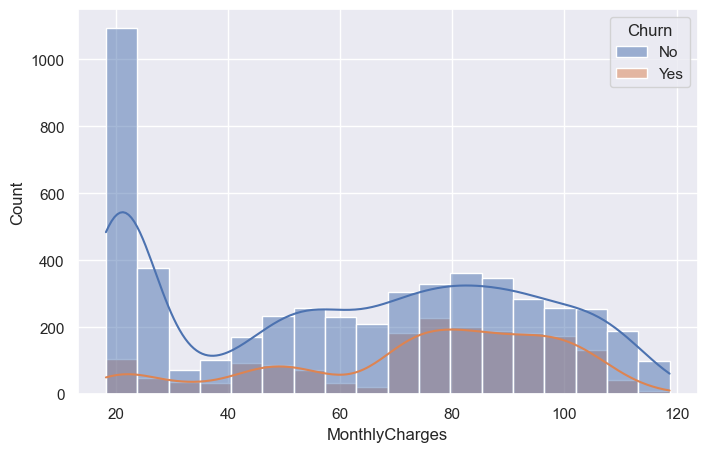

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="MonthlyCharges",
    hue="Churn",
    kde=True
)

plt.show()

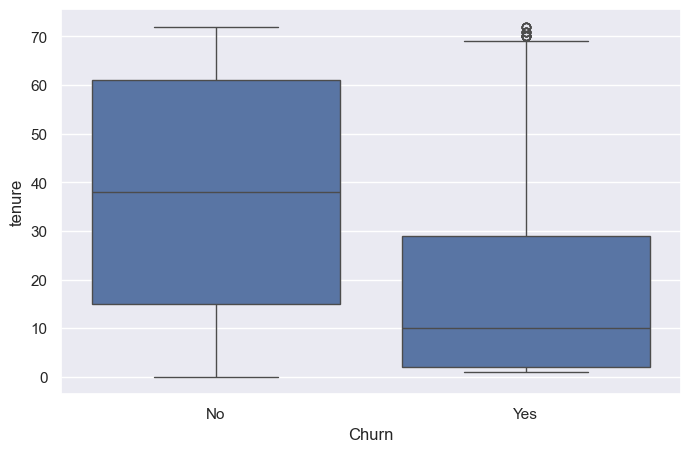

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="tenure",
    data=df
)

plt.show()

In [13]:
df["TotalCharges"].head(10)


0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: str

In [14]:
df["TotalCharges"].dtype

<StringDtype(na_value=nan)>

In [15]:
df[df["TotalCharges"] == " "].shape

(11, 21)

In [16]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [17]:
df["TotalCharges"].dtype

dtype('float64')

In [18]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [19]:
NaN

NameError: name 'NaN' is not defined

In [20]:
df = df.dropna()

In [21]:
df.shape

(7032, 21)

In [22]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [23]:
df = df.drop("customerID", axis=1)

In [24]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

# Data Cleaning

- Converted TotalCharges to numeric
- Identified 11 missing values
- Removed missing records
- Dropped customerID column

In [26]:
df = df.dropna()

In [27]:
for col in df.columns:
    print(f"\n{col}")
    print(df[col].unique())


gender
<ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str

SeniorCitizen
[0 1]

Partner
<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str

Dependents
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

tenure
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26 39]

PhoneService
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

MultipleLines
<ArrowStringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

InternetService
<ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

OnlineSecurity
<ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

OnlineBackup
<ArrowStringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

DeviceProtection
<ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

TechSupport
<ArrowStrin

In [28]:
df.dtypes

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [29]:
df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

In [30]:
df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [31]:
df_model = df.copy()

In [32]:
for col in df_model.select_dtypes(include="object").columns:
    print(f"\n{col}")
    print(df_model[col].nunique())


gender
2

Partner
2

Dependents
2

PhoneService
2

MultipleLines
3

InternetService
3

OnlineSecurity
3

OnlineBackup
3

DeviceProtection
3

TechSupport
3

StreamingTV
3

StreamingMovies
3

Contract
3

PaperlessBilling
2

PaymentMethod
4


C:\Users\nagat\AppData\Local\Temp\ipykernel_3200\707542758.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_model.select_dtypes(include="object").columns:


In [33]:
df_encoded = pd.get_dummies(
    df_model,
    drop_first=True,
    dtype=int
)

In [34]:
df_encoded.shape

(7032, 31)

In [35]:
df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0


In [36]:
X = df_encoded.drop("Churn", axis=1)

y = df_encoded["Churn"]

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [38]:
X_train.shape, X_test.shape

((5625, 30), (1407, 30))

In [39]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

C:\Users\nagat\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [40]:
predictions = model.predict(X_test)

In [41]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, predictions)

0.8031272210376688

In [42]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [43]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)

cm

array([[915, 118],
       [159, 215]])

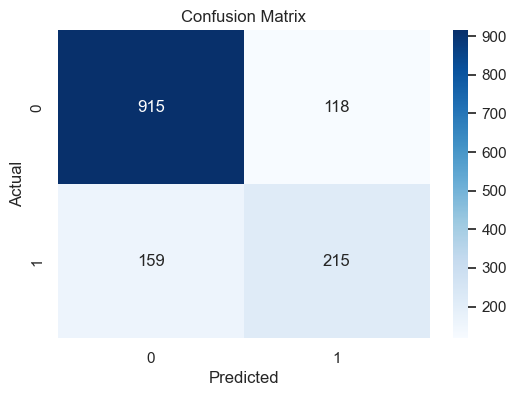

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [45]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [46]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [47]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, rf_pred)

0.7867803837953091

In [48]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [49]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

feature_importance = feature_importance.sort_values(
    by="Coefficient",
    ascending=False
)

feature_importance.head(15)

,Feature,Coefficient
10,InternetService_Fiber optic,0.683630
28,PaymentMethod_Electronic check,0.390160
26,PaperlessBilling_Yes,0.298448
9,MultipleLines_Yes,0.278615
8,MultipleLines_No phone service,0.252229
21,StreamingTV_Yes,0.205085
0,SeniorCitizen,0.196803
23,StreamingMovies_Yes,0.176875
29,PaymentMethod_Mailed check,0.077059
27,PaymentMethod_Credit card (automatic),0.038419


In [50]:
feature_importance.tail(15)

,Feature,Coefficient
1,tenure,-0.057110
14,OnlineBackup_No internet service,-0.106049
12,OnlineSecurity_No internet service,-0.106049
11,InternetService_No,-0.106049
22,StreamingMovies_No internet service,-0.106049
18,TechSupport_No internet service,-0.106049
16,DeviceProtection_No internet service,-0.106049
20,StreamingTV_No internet service,-0.106049
15,OnlineBackup_Yes,-0.213131
6,Dependents_Yes,-0.229427


# Key Business Insights

## High Churn Risk Factors
- Fiber optic internet customers are more likely to churn.
- Customers paying through electronic checks show higher churn.
- Paperless billing customers have increased churn probability.

## Customer Retention Factors
- Two-year contract customers are least likely to churn.
- Online security and tech support significantly reduce churn.
- Customers with dependents show lower churn rates.

In [52]:
import joblib


In [53]:
joblib.dump(model, "../models/churn_model.pkl")

['../models/churn_model.pkl']

In [54]:
joblib.dump(model, "models/churn_model.pkl")

FileNotFoundError: [Errno 2] No such file or directory: 'models/churn_model.pkl'

In [55]:
import os

In [56]:

print(os.getcwd())

C:\Users\nagat\OneDrive\Desktop\Customer-Churn-Prediction\notebooks


In [57]:
os.listdir()

['.ipynb_checkpoints',
 '01_data_understanding.ipynb',
 '01_data_understanding_and_cleaning.ipynb']

In [58]:
joblib.dump(model, "../models/churn_model.pkl")

['../models/churn_model.pkl']

In [59]:
joblib.dump(model, "models/churn_model.pkl")

FileNotFoundError: [Errno 2] No such file or directory: 'models/churn_model.pkl'

In [60]:
os.path.exists("../models")

True

In [61]:
import joblib

joblib.dump(
    model,
    "../models/churn_model.pkl"
)

['../models/churn_model.pkl']

In [62]:
import joblib

joblib.dump(
    model,
    "../models/churn_model.pkl"
)

['../models/churn_model.pkl']

In [63]:
import joblib


In [64]:
joblib.dump(
    model,
    "../models/churn_model.pkl"
)

['../models/churn_model.pkl']

In [65]:
joblib.dump(
    model,
    "../models/churn_model.pkl"
)

['../models/churn_model.pkl']

In [66]:
joblib.dump(
    X.columns.tolist(),
    "../models/columns.pkl"
)

['../models/columns.pkl']

In [67]:
import os

os.listdir("../models")

['churn_model.pkl', 'columns.pkl']

In [68]:
len(X.columns)

30

In [69]:
X.columns.tolist()

['SeniorCitizen',
 'tenure',
 'MonthlyCharges',
 'TotalCharges',
 'gender_Male',
 'Partner_Yes',
 'Dependents_Yes',
 'PhoneService_Yes',
 'MultipleLines_No phone service',
 'MultipleLines_Yes',
 'InternetService_Fiber optic',
 'InternetService_No',
 'OnlineSecurity_No internet service',
 'OnlineSecurity_Yes',
 'OnlineBackup_No internet service',
 'OnlineBackup_Yes',
 'DeviceProtection_No internet service',
 'DeviceProtection_Yes',
 'TechSupport_No internet service',
 'TechSupport_Yes',
 'StreamingTV_No internet service',
 'StreamingTV_Yes',
 'StreamingMovies_No internet service',
 'StreamingMovies_Yes',
 'Contract_One year',
 'Contract_Two year',
 'PaperlessBilling_Yes',
 'PaymentMethod_Credit card (automatic)',
 'PaymentMethod_Electronic check',
 'PaymentMethod_Mailed check']

In [70]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [71]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(
    y_test,
    dt_pred
)

print(dt_accuracy)

0.7185501066098081


In [72]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print(rf_accuracy)

0.7896233120113717


In [73]:
comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        0.8031,
        0.7186,
        0.7896
    ]
})

comparison_df

,Model,Accuracy
0,Logistic Regression,0.8031
1,Decision Tree,0.7186
2,Random Forest,0.7896


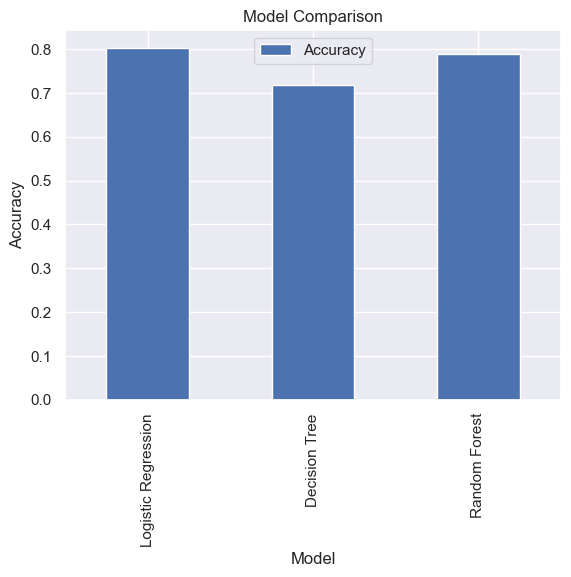

In [74]:
import matplotlib.pyplot as plt

comparison_df.plot(
    x="Model",
    y="Accuracy",
    kind="bar"
)

plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

## Model Comparison Conclusion

Three machine learning models were trained and evaluated:

- Logistic Regression
- Decision Tree
- Random Forest

Logistic Regression achieved the highest test accuracy of 80.31%.

Therefore Logistic Regression was selected as the final production model for deployment in the Streamlit application.

In [76]:
rf_model_2 = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=10,
    random_state=42
)

rf_model_2.fit(X_train, y_train)

rf_pred_2 = rf_model_2.predict(X_test)

print(
    accuracy_score(
        y_test,
        rf_pred_2
    )
)

0.7910447761194029


In [77]:
import shap

print(shap.__version__)

0.52.0


In [78]:
import shap

explainer = shap.Explainer(
    model,
    X_train
)

print("Explainer Created Successfully")

Background dataset has 5625 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5625 when initializing the masker.


Explainer Created Successfully


In [79]:
shap_values = explainer(X_test)

print(shap_values.shape)

(1407, 30)


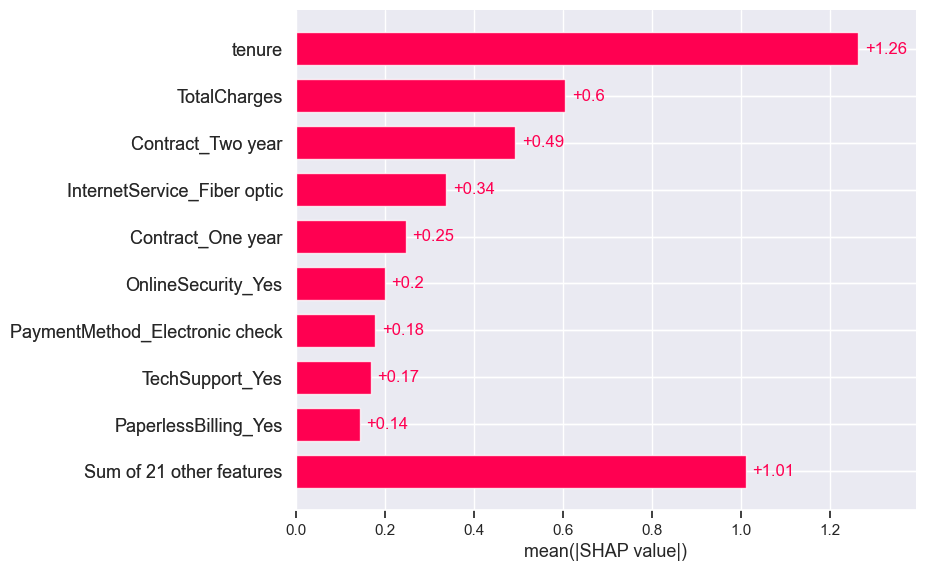

In [80]:
shap.plots.bar(shap_values)

In [81]:
shap_values = explainer(X_test)

print(shap_values.shape)

(1407, 30)


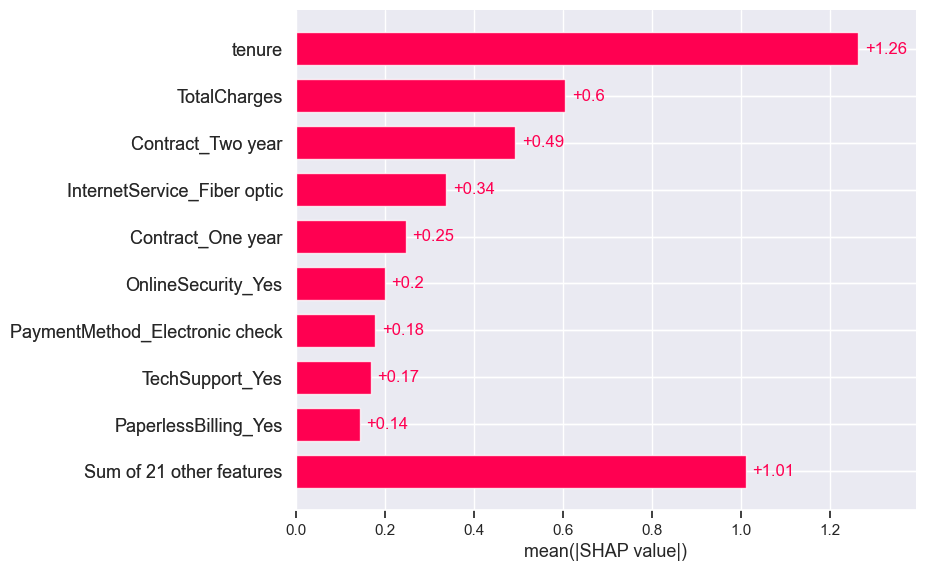

In [82]:
shap.plots.bar(shap_values)

## SHAP Explainability Results

SHAP analysis was performed to interpret the churn prediction model.

Key findings:

- Month-to-month contracts strongly increase churn probability
- Higher monthly charges are associated with higher churn
- Longer tenure reduces churn risk
- Certain internet service types increase churn likelihood

This confirms that the model is aligned with real-world telecom behavior.

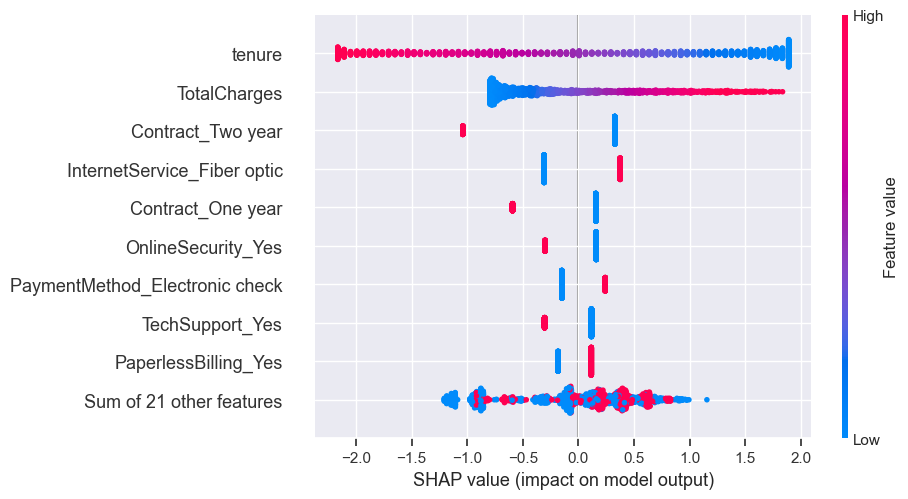

In [83]:
shap.plots.beeswarm(shap_values)

## Business Insights from SHAP

- Customers on month-to-month contracts are most likely to churn.
- Higher monthly charges increase churn probability.
- Longer tenure significantly reduces churn risk.
- Fiber optic users show higher churn tendency.
- Lack of support services increases churn risk.

In [85]:
import joblib

joblib.dump(model, "churn_model.pkl")

['churn_model.pkl']

In [87]:
joblib.dump(X_train.columns, "features.pkl")

['features.pkl']